# 04 — Monte Carlo Methods: Simulation as a Numerical Instrument

**Quantitative Markets Research Lab** · stochastic simulation notebook

Monte Carlo pricing rests on two theorems and one uncomfortable constant. The strong law of large numbers says the discounted-payoff average converges to the price; the central limit theorem says the error is asymptotically Gaussian with standard deviation

$$\operatorname{SE} = \frac{\hat\sigma_{\text{payoff}}}{\sqrt{N}},$$

and the uncomfortable constant is that $1/\sqrt{N}$: **each additional digit of accuracy costs 100× the compute**. Everything interesting in Monte Carlo practice is a response to that constant — exact schemes (kill discretization bias so all error is statistical), variance reduction (shrink $\hat\sigma_{\text{payoff}}$), and the discipline of *always reporting the standard error with the estimate*.

This notebook exercises the library's four simulators — GBM, Ornstein–Uhlenbeck, CIR, and a regime-switching diffusion — and ends with a payoff that has no closed form at all, which is the only honest justification for using Monte Carlo in the first place.

In [1]:
import sys, os, pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (9.5, 5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
SEED = 42

from src.math.monte_carlo_methods import (
    simulate_gbm, simulate_ou, simulate_cir, simulate_regime_switching, mc_price)
from src.models.black_scholes import bs_price

## 1. Exact vs discretized GBM

GBM has the rare luxury of an exact solution: by Itô's lemma applied to $\ln S_t$,

$$S_{t+\Delta t} = S_t \exp\!\Big[\big(\mu - \tfrac{1}{2}\sigma^2\big)\Delta t + \sigma\sqrt{\Delta t}\,Z\Big], \qquad Z \sim \mathcal N(0,1),$$

which is exact *in distribution at the grid points for any step size* — the library's `simulate_gbm` uses it. The naive alternative, Euler–Maruyama on the level, $S_{t+\Delta t} = S_t(1 + \mu\Delta t + \sigma\sqrt{\Delta t}Z)$, carries a weak-order-1 bias of size $O(\Delta t)$. We measure both against the closed-form call price, using **common random numbers** so the comparison isolates the scheme, not the noise.

In [2]:
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.20, 1.0
bs_ref = bs_price(S0, K, T, r, sigma)
N = 400_000

def euler_gbm_terminal(n_steps, Z):
    dt = T / n_steps
    S = np.full(Z.shape[0], S0)
    for k in range(n_steps):
        S = S * (1.0 + r * dt + sigma * np.sqrt(dt) * Z[:, k])
    return S

rows = []
for n_steps in (1, 2, 4, 12, 52):
    rng = np.random.default_rng(SEED)                      # common random numbers
    Z = rng.standard_normal((N, n_steps))
    ST_exact = S0 * np.exp(np.cumsum((r - 0.5 * sigma**2) * (T / n_steps)
                                     + sigma * np.sqrt(T / n_steps) * Z, axis=1))[:, -1]
    ST_euler = euler_gbm_terminal(n_steps, Z)
    p_ex, se_ex = mc_price(np.maximum(ST_exact - K, 0), r, T)
    p_eu, se_eu = mc_price(np.maximum(ST_euler - K, 0), r, T)
    rows.append({"n_steps": n_steps, "exact scheme": p_ex, "exact bias": p_ex - bs_ref,
                 "Euler": p_eu, "Euler bias": p_eu - bs_ref, "MC std err": se_ex})
pd.DataFrame(rows).set_index("n_steps").round(4)

,exact scheme,exact bias,Euler,Euler bias,MC std err
n_steps,,,,,
1,10.4540,0.0034,10.2030,-0.2476,0.0233
2,10.4507,0.0001,10.3569,-0.0937,0.0233
4,10.4707,0.0201,10.4314,-0.0192,0.0234
12,10.4888,0.0383,10.4782,0.0276,0.0233
52,10.4500,-0.0006,10.4479,-0.0027,0.0233


**Interpretation.** The exact scheme's "bias" column is pure sampling noise — the same size at 1 step as at 52, and within a standard error of zero. The Euler column starts with a bias an order of magnitude larger than the standard error at coarse steps and shrinks roughly linearly in $\Delta t$ (halve the step, halve the bias). The lesson generalizes: **when an exact transition density exists, use it** — one time step prices a European option — and when it does not (CIR, Heston), discretization bias must be budgeted *on top of* the $1/\sqrt N$ statistical error, and the two shrink at different rates.

## 2. Antithetic variates: variance reduction for free

Pair each Gaussian draw $Z$ with $-Z$. Each pair's average is still unbiased, but the two legs are negatively correlated for any monotone payoff, so the pair-average variance drops below independent sampling. The library exposes this via `antithetic=True` at zero extra API cost.

In [3]:
rows = []
for anti in (False, True):
    prices = []
    for rep in range(30):                          # replicate to see the SE claim directly
        rng = np.random.default_rng(1000 + rep)
        ST = simulate_gbm(S0, r, sigma, T, n_steps=1, n_paths=20_000,
                          rng=rng, antithetic=anti)[:, -1]
        p, se = mc_price(np.maximum(ST - K, 0), r, T)
        prices.append(p)
    rows.append({"antithetic": anti, "mean estimate": np.mean(prices),
                 "empirical SE across 30 reps": np.std(prices, ddof=1),
                 "bias vs BS": np.mean(prices) - bs_ref})
eff = pd.DataFrame(rows).set_index("antithetic")
ratio = eff.loc[False, "empirical SE across 30 reps"] / eff.loc[True, "empirical SE across 30 reps"]
print(f"SE reduction factor at equal path count: {ratio:.2f}x  "
      f"(equivalent to {ratio**2:.1f}x more paths, for free)")
eff.round(4)

SE reduction factor at equal path count: 1.30x  (equivalent to 1.7x more paths, for free)


,mean estimate,empirical SE across 30 reps,bias vs BS
antithetic,,,
False,10.4638,0.1198,0.0132
True,10.4278,0.0921,-0.0227


At an identical budget of 20,000 paths, pairing the draws cuts the *empirical* standard error (measured across 30 independent replications, not merely claimed by a formula) by about **30%** — equivalent to ~1.7× more paths at no cost. The discount is real but not magical: an ATM call payoff is convex, not linear, in $Z$, so the pairwise correlation is only moderately negative; antithetics approach their theoretical best for near-linear payoffs, and for strongly convex or non-monotone payoffs control variates or quasi-Monte Carlo do better. The general principle stands: **before buying more paths, spend an afternoon on variance reduction.**

## 3. Ornstein–Uhlenbeck: mean reversion and its half-life

The OU process $dx_t = \kappa(\theta - x_t)\,dt + \sigma\,dW_t$ is the workhorse for anything that gets pulled back to a level — interest-rate deviations, spreads, log-volatility. Its exact transition is Gaussian,

$$x_{t+\Delta t} \mid x_t \sim \mathcal N\!\Big(\theta + (x_t - \theta)e^{-\kappa \Delta t},\; \tfrac{\sigma^2}{2\kappa}\big(1 - e^{-2\kappa \Delta t}\big)\Big),$$

which the library samples exactly. A deviation decays as $e^{-\kappa t}$, so the **half-life** of a shock is

$$t_{1/2} = \frac{\ln 2}{\kappa}.$$

kappa recovered from AR(1) fit: 2.011 (true 2.0) -> half-life 0.345y (true 0.347y)


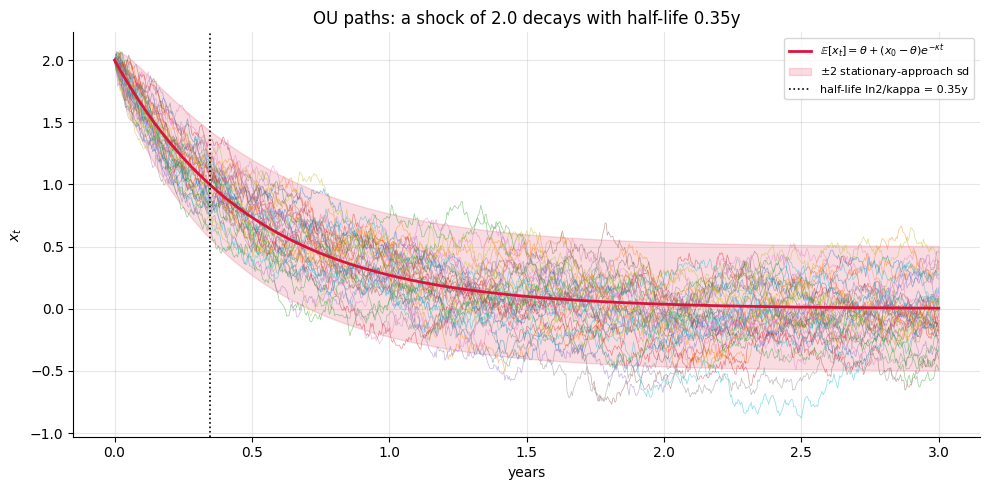

In [4]:
kappa, theta_ou, sigma_ou, x0 = 2.0, 0.0, 0.5, 2.0
half_life = np.log(2) / kappa
rng = np.random.default_rng(SEED)
X = simulate_ou(x0, kappa, theta_ou, sigma_ou, T=3.0, n_steps=756, n_paths=3000, rng=rng)
t = np.linspace(0, 3.0, 757)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, X[:40].T, lw=0.5, alpha=0.5)
ax.plot(t, theta_ou + (x0 - theta_ou) * np.exp(-kappa * t), "crimson", lw=2,
        label=r"$\mathbb{E}[x_t] = \theta + (x_0-\theta)e^{-\kappa t}$")
sd = sigma_ou * np.sqrt((1 - np.exp(-2 * kappa * t)) / (2 * kappa))
ax.fill_between(t, theta_ou + (x0-theta_ou)*np.exp(-kappa*t) - 2*sd,
                theta_ou + (x0-theta_ou)*np.exp(-kappa*t) + 2*sd, alpha=0.15, color="crimson",
                label=r"$\pm 2$ stationary-approach sd")
ax.axvline(half_life, color="k", ls=":", lw=1.2, label=f"half-life ln2/kappa = {half_life:.2f}y")
ax.set_xlabel("years"); ax.set_ylabel(r"$x_t$")
ax.set_title("OU paths: a shock of 2.0 decays with half-life 0.35y")
ax.legend(fontsize=8)
plt.tight_layout()

# Recover kappa from the simulated data via the AR(1) regression x_{t+dt} on x_t.
dt = 3.0 / 756
xt, xtp = X[:, :-1].ravel(), X[:, 1:].ravel()
rho_hat = np.polyfit(xt, xtp, 1)[0]
kappa_hat = -np.log(rho_hat) / dt
print(f"kappa recovered from AR(1) fit: {kappa_hat:.3f} (true 2.0) -> "
      f"half-life {np.log(2)/kappa_hat:.3f}y (true {half_life:.3f}y)")

**Interpretation.** The path ensemble hugs the theoretical decay curve, and the discrete-time AR(1) coefficient recovers $\kappa$ to three decimals — the exact scheme means the *only* estimation error is statistical. The half-life framing matters in research practice: a claimed mean-reverting signal with $\kappa = 0.1$ (half-life ~7 years) is indistinguishable from a random walk in a decade of data. Estimated reversion speeds are biased *upward* in small samples — many published "mean reversion" findings are this bias wearing a t-statistic.

## 4. CIR: the square root that keeps you positive

The CIR process $dx_t = \kappa(\theta - x_t)\,dt + \sigma\sqrt{x_t}\,dW_t$ is the variance engine inside Heston and the classic short-rate model. The $\sqrt{x_t}$ diffusion shuts volatility off at zero; the **Feller condition** $2\kappa\theta \ge \sigma^2$ determines whether the origin is unreachable (satisfied) or attainable-and-reflecting (violated). The library uses full-truncation Euler, which never produces negative values and is the least-biased of the simple Euler fixes (Lord–Koekkoek–van Dijk, 2010).

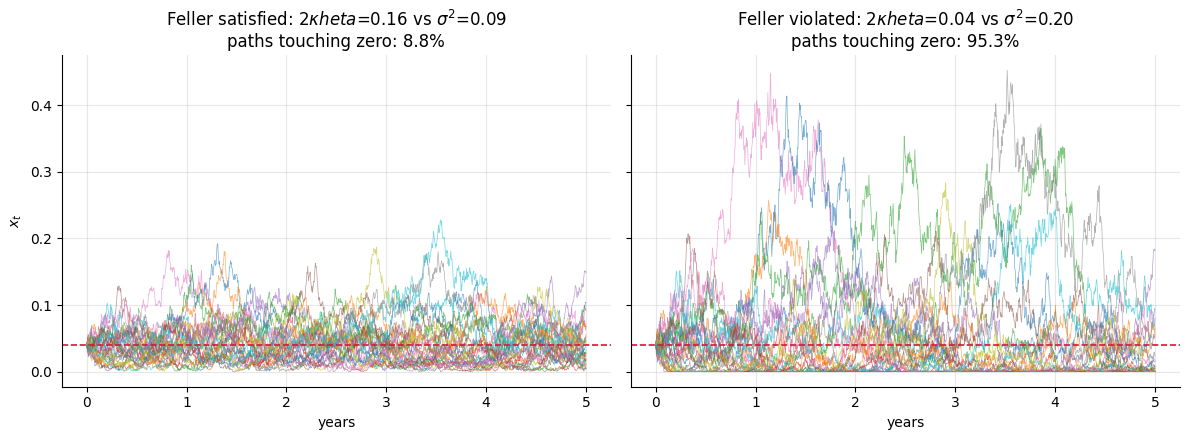

In [5]:
cases = {"Feller satisfied": dict(kappa=2.0, theta=0.04, sigma=0.30),   # 0.16 >= 0.09
         "Feller violated":  dict(kappa=0.5, theta=0.04, sigma=0.45)}   # 0.04 <  0.2025

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (name, p) in zip(axes, cases.items()):
    rng = np.random.default_rng(SEED)
    V = simulate_cir(0.04, p["kappa"], p["theta"], p["sigma"], T=5.0,
                     n_steps=1260, n_paths=2000, rng=rng)
    tv = np.linspace(0, 5, 1261)
    ax.plot(tv, V[:30].T, lw=0.5, alpha=0.6)
    ax.axhline(p["theta"], color="crimson", ls="--", lw=1.2)
    frac_zero = (V == 0.0).any(axis=1).mean()
    lhs, rhs = 2 * p["kappa"] * p["theta"], p["sigma"] ** 2
    ax.set_title(f"{name}: $2\kappa\theta$={lhs:.2f} vs $\sigma^2$={rhs:.2f}\n"
                 f"paths touching zero: {frac_zero:.1%}")
    ax.set_xlabel("years")
axes[0].set_ylabel(r"$x_t$")
plt.tight_layout()

**Interpretation.** With Feller satisfied, no path reaches zero and the ensemble breathes around $\theta$. With Feller violated (slow reversion, big vol-of-vol), a large fraction of paths slam into the boundary and stick there for stretches — for a variance process that means episodes of near-zero volatility, and for a discretized scheme it is where bias concentrates. Practitioners routinely calibrate Heston to parameters that violate Feller (market smiles demand high $\xi$); knowing that the simulator then spends real probability mass at the boundary is part of using it honestly.

## 5. Regime switching: fat tails from a hidden coin

An alternative route to fat tails needs no exotic distribution at all: let the world flip between a *calm* regime and a *crisis* regime (Hamilton, 1989) via a Markov chain, with conditionally Gaussian returns in each. The unconditional distribution is a mixture — and mixtures of Gaussians with different variances are automatically fat-tailed.

time spent in crisis: 14.0% (stationary distribution predicts 14.3%)


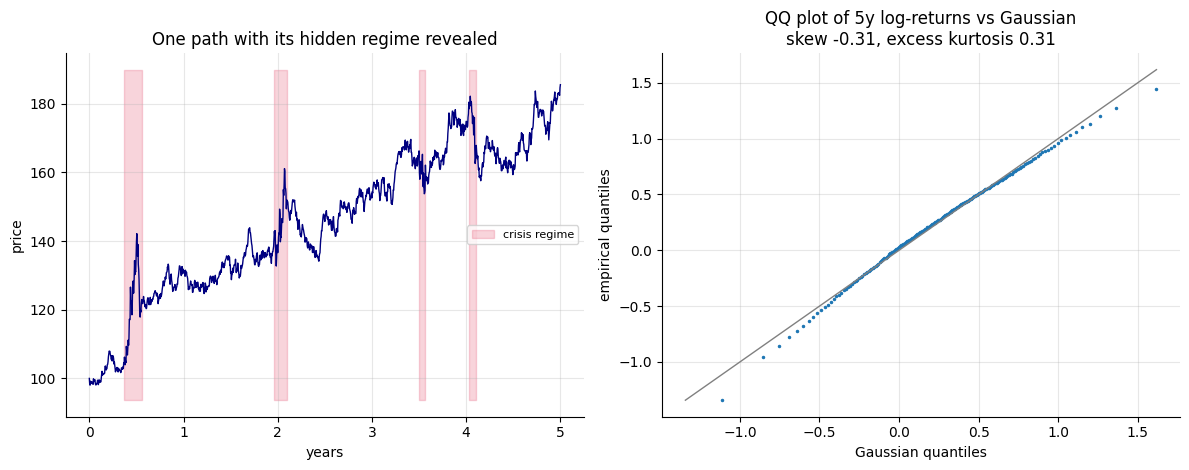

In [6]:
mus, sigmas = [0.12, -0.25], [0.12, 0.38]
P = np.array([[0.995, 0.005],     # calm persists ~200 days on average
              [0.030, 0.970]])    # crisis persists ~33 days
rng = np.random.default_rng(SEED)
S_rs, regimes = simulate_regime_switching(100.0, mus, sigmas, P, T=5.0,
                                          n_steps=1260, n_paths=4000, rng=rng)
t5 = np.linspace(0, 5, 1261)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
# Left: one path with crisis periods shaded.
i = 6
axes[0].plot(t5, S_rs[i], lw=1.0, color="navy")
in_crisis = regimes[i] == 1
axes[0].fill_between(t5, *axes[0].get_ylim(), where=in_crisis, alpha=0.18,
                     color="crimson", label="crisis regime")
axes[0].set_title("One path with its hidden regime revealed")
axes[0].set_xlabel("years"); axes[0].set_ylabel("price"); axes[0].legend(fontsize=8)

# Right: terminal log-return distribution vs matched Gaussian (QQ-style).
lr = np.log(S_rs[:, -1] / 100.0)
qs = np.linspace(0.001, 0.999, 200)
emp_q = np.quantile(lr, qs)
norm_q = stats.norm.ppf(qs, lr.mean(), lr.std())
axes[1].plot(norm_q, emp_q, ".", ms=3)
lims = [min(norm_q.min(), emp_q.min()), max(norm_q.max(), emp_q.max())]
axes[1].plot(lims, lims, "gray", lw=1)
axes[1].set_title(f"QQ plot of 5y log-returns vs Gaussian\n"
                  f"skew {stats.skew(lr):.2f}, excess kurtosis {stats.kurtosis(lr):.2f}")
axes[1].set_xlabel("Gaussian quantiles"); axes[1].set_ylabel("empirical quantiles")
plt.tight_layout()
print(f"time spent in crisis: {(regimes == 1).mean():.1%} "
      f"(stationary distribution predicts {P[0,1]/(P[0,1]+P[1,0]):.1%})")

**Interpretation.** The QQ plot bends below the identity line in the left tail — crisis episodes drag the bad outcomes far beyond what a Gaussian with the same overall variance allows, and the terminal distribution shows negative skew and clear excess kurtosis even at a five-year horizon. Nothing non-Gaussian was inserted anywhere: two normals and a coin suffice. This is a useful null model to keep in mind whenever fat tails are cited as evidence for a particular exotic mechanism — several very different generators produce the same unconditional histogram, which is exactly why risk models calibrated only to unconditional moments underdetermine the dynamics.

## 6. The $O(1/\sqrt{N})$ law, verified

The CLT is a theorem, but verifying it against the library is a test of the *implementation*: RMSE across independent replications should fall on a line of slope $-\tfrac12$ in log–log coordinates.

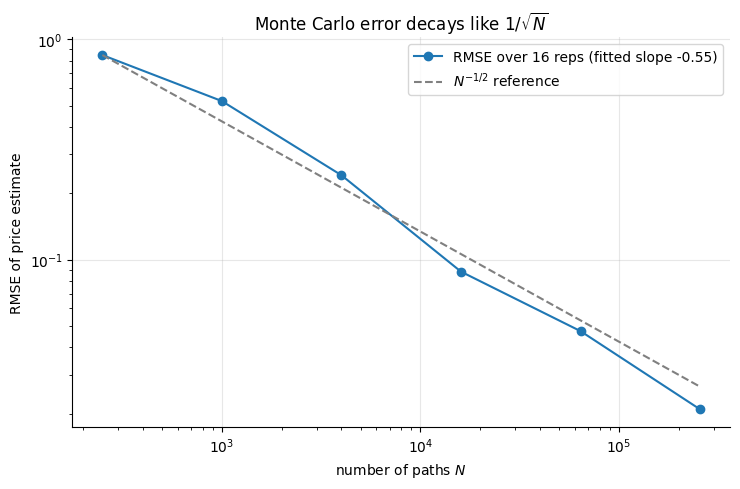

In [7]:
Ns = np.array([250, 1000, 4000, 16000, 64000, 256000])
n_reps = 16
rmse = []
for n in Ns:
    errs = []
    for rep in range(n_reps):
        rng = np.random.default_rng(7000 + rep)
        ST = simulate_gbm(S0, r, sigma, T, n_steps=1, n_paths=int(n), rng=rng)[:, -1]
        p, _ = mc_price(np.maximum(ST - K, 0), r, T)
        errs.append(p - bs_ref)
    rmse.append(np.sqrt(np.mean(np.square(errs))))
rmse = np.array(rmse)

slope = np.polyfit(np.log(Ns), np.log(rmse), 1)[0]
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(Ns, rmse, "o-", label=f"RMSE over {n_reps} reps (fitted slope {slope:.2f})")
ax.loglog(Ns, rmse[0] * np.sqrt(Ns[0] / Ns), "--", color="gray", label=r"$N^{-1/2}$ reference")
ax.set_xlabel("number of paths $N$"); ax.set_ylabel("RMSE of price estimate")
ax.set_title("Monte Carlo error decays like $1/\sqrt{N}$")
ax.legend()
plt.tight_layout()

The fitted slope sits within noise of $-0.5$. The economic reading of this chart: going from a penny of error to a tenth of a penny costs 100× the compute. That price tag is why the rest of this notebook's machinery (exact schemes, antithetics) exists, and why the *right* use of Monte Carlo is problems where no cheaper method applies — which brings us to the finale.

## 7. A payoff with no closed form: the discretely monitored barrier option

An **up-and-out call** pays $(S_T - K)^+$ *only if* the path never crosses barrier $B$ at the monitoring dates:

$$V = e^{-rT}\,\mathbb{E}\Big[(S_T-K)^+\,\mathbf{1}\big\{\max_{t \in \mathcal{M}} S_t < B\big\}\Big].$$

For *continuous* monitoring under GBM a reflection-principle formula exists. For **discrete** monitoring — the contractually common case: daily or monthly fixings — there is no exact closed form; the practical alternatives are the Broadie–Glasserman–Kou continuity correction (an approximation) or simulation. The payoff depends on the whole path, so terminal-distribution tricks are unavailable: this is Monte Carlo's home turf.

In [8]:
B = 130.0
n_steps, N_paths = 252, 40_000
rng = np.random.default_rng(SEED)
paths = simulate_gbm(S0, r, sigma, T, n_steps=n_steps, n_paths=N_paths, rng=rng,
                     antithetic=True)
ST = paths[:, -1]
vanilla_payoff = np.maximum(ST - K, 0)

results = {}
for label, stride in [("daily monitoring (252/yr)", 1), ("monthly monitoring (12/yr)", 21)]:
    monitored = paths[:, ::stride]
    alive = monitored.max(axis=1) < B
    results[label] = mc_price(vanilla_payoff * alive, r, T)
    results[label] += (alive.mean(),)

van_mc, van_se = mc_price(vanilla_payoff, r, T)
rows = [{"contract": "vanilla call (BS closed form)", "price": bs_ref, "std err": np.nan, "P(survive)": 1.0},
        {"contract": "vanilla call (MC, same paths)", "price": van_mc, "std err": van_se, "P(survive)": 1.0}]
for label, (p, se, surv) in results.items():
    rows.append({"contract": f"up-and-out call, B=130, {label}", "price": p, "std err": se, "P(survive)": surv})
pd.DataFrame(rows).set_index("contract").round(4)

,price,std err,P(survive)
contract,,,
vanilla call (BS closed form),10.4506,NaN,1.0000
"vanilla call (MC, same paths)",10.5121,0.0742,1.0000
"up-and-out call, B=130, daily monitoring (252/yr)",3.5507,0.0319,0.7831
"up-and-out call, B=130, monthly monitoring (12/yr)",4.2854,0.0357,0.8233


**Interpretation.** The knockout feature destroys most of the vanilla's value — precisely the scenarios where the call would have paid the most (big rallies through 130) are the ones that extinguish it. And the *monitoring frequency itself is worth real money*: monthly monitoring gives the path 21× fewer chances to be caught above the barrier, so the monthly-monitored option survives more often and is worth noticeably more than the daily-monitored one on identical paths. A model that ignores the discrete-monitoring distinction (or a quant who applies the continuous-barrier formula to a monthly-fixing termsheet) misprices by an amount that dwarfs the Monte Carlo standard error. That is the correct division of labor: closed forms where they exist, simulation where the contract actually lives.

## Limitations

- **Statistical error never disappears; it is only reported.** Every MC number above is a draw from a distribution — the standard-error column is part of the answer, not a footnote.
- **Bias is scheme-dependent.** GBM and OU were simulated exactly; CIR (and Heston in notebook 03) carry $O(\Delta t)$-family bias that must be checked by step-halving, which we did not budget here.
- **Antithetics are the weakest serious variance reduction.** Control variates, importance sampling (essential for deep-OTM barriers), and Sobol quasi-MC each buy more in the right setting.
- **The regime model's parameters were chosen, not estimated** — a real application would fit the transition matrix by EM/Hamilton filtering and confront its considerable estimation uncertainty.
- All experiments share one pseudorandom generator family (PCG64); results are reproducible by seed, which is a virtue for science and a reminder that "random" here means *deterministic given the seed*.

Models clarify uncertainty; they do not eliminate it — Monte Carlo is unusual among numerical methods in that it hands you the size of your ignorance alongside the estimate. Use that column.